In [1]:
import os
import sys

sys.path.append(os.path.dirname(os.getcwd())) 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
DATA_DIR = '../data/'
stage2_dir = os.path.join(DATA_DIR, 'stage2_netrating')


In [4]:
date = '20241022'
stage2_output = os.path.join(stage2_dir, f'df_test_stage2_effort_{date}.csv')
stage2_train = os.path.join(stage2_dir, f'df_train_stage2_effort_{date}.csv')
df = pd.read_csv(stage2_output)
df_train = pd.read_csv(stage2_train)

In [5]:
df.rename(columns={'y_pred_test':'pred_nrtg'}, inplace=True)
df

,SEASON_ID,GAME_ID,GAME_DATE,HOME_TEAM_ID,AWAY_TEAM_ID,HOME_TEAM,AWAY_TEAM,HOME_AVG10_NET_COMPOSITE_EFFORT,AWAY_AVG10_NET_COMPOSITE_EFFORT,AVG10_EFG_PCT_DIFF,AVG10_FTA_RATE_DIFF,AVG10_TM_TOV_PCT_DIFF,AVG10_OREB_PCT_DIFF,AVG10_NET_COMPOSITE_EFFORT_DIFF,pred_nrtg
0,22024,22400061,2024-10-22,1610612738,1610612752,BOS,NYK,16.950916,18.171884,0.0222,-0.0866,-0.0121,-0.0438,-1.220968,3.272845
1,22024,22400062,2024-10-22,1610612747,1610612750,LAL,MIN,15.577461,16.836173,0.0177,-0.0182,0.0120,-0.0067,-1.258712,2.149552


In [6]:
df_train.head()

,SEASON_ID,GAME_ID,GAME_DATE,HOME_TEAM_ID,AWAY_TEAM_ID,HOME_TEAM,AWAY_TEAM,HOME_AVG10_NET_COMPOSITE_EFFORT,AWAY_AVG10_NET_COMPOSITE_EFFORT,AVG10_EFG_PCT_DIFF,AVG10_FTA_RATE_DIFF,AVG10_TM_TOV_PCT_DIFF,AVG10_OREB_PCT_DIFF,AVG10_NET_COMPOSITE_EFFORT_DIFF,y_pred_train
0,22022,22200001,2022-10-18,1610612738,1610612755,BOS,PHI,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.378131
1,22022,22200002,2022-10-18,1610612744,1610612747,GSW,LAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.378131
2,22022,22200003,2022-10-19,1610612765,1610612753,DET,ORL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.378131
3,22022,22200004,2022-10-19,1610612754,1610612764,IND,WAS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.378131
4,22022,22200005,2022-10-19,1610612737,1610612745,ATL,HOU,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.378131


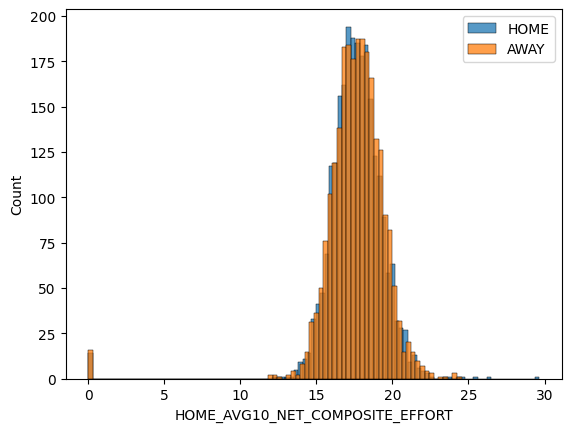

In [9]:
sns.histplot(df_train['HOME_AVG10_NET_COMPOSITE_EFFORT'], label='HOME')
sns.histplot(df_train['AWAY_AVG10_NET_COMPOSITE_EFFORT'], label='AWAY')
plt.legend(loc='best')

In [10]:
df_train['HOME_AVG10_NET_COMPOSITE_EFFORT'].describe()

count    2460.000000
mean       17.591615
std         2.033071
min         0.000000
25%        16.664988
50%        17.654346
75%        18.622179
max        29.643219
Name: HOME_AVG10_NET_COMPOSITE_EFFORT, dtype: float64

In [11]:
df_train['AWAY_AVG10_NET_COMPOSITE_EFFORT'].describe()

count    2460.000000
mean       17.622596
std         2.107649
min         0.000000
25%        16.678343
50%        17.696368
75%        18.748264
max        24.542279
Name: AWAY_AVG10_NET_COMPOSITE_EFFORT, dtype: float64

## Effort Interpretations
1. $\text{Offensive Effort} = 0.15 X_{OFF\_BOXOUTS} + 0.63X_{SCREEN\_AST} - 0.12X_{OFF\_LOOSE\_BALLS\_RECOVERED}$
2. $\text{Defensive Effort} = -0.35X_{DEFLECTIONS}+0.09X_{CONTESTED\_3PT}-0.22X_{CONTESTED\_2PT}-0.69X_{DEF\_LOOSE\_BALLS\_RECOVERED}-0.84X_{CHARGES\_DRAWN}-0.43X_{DEF\_BOXOUTS}$

Both of the offensive and defensive effort metrics are in terms of points scored per 100 possessions (above zero offensive effort) and points allowed per 100 possessions (below zero defensive effort), respectively.

- Example 1 - If all offensive hustle metrics had value of 10 --> $\text{Offensive Effort} = 6.6$. This means with this many offensive effort plays, we'd expect the team to score 6.6 points per 100 possessions more.

- Example 2 - If all defensive hustle metrics had value of 10 --> $\text{Defensive Effort} = -24.4$. This means with this many defensive effort plays, we'd expect the team to prevent 24.4 points per 100 possessions more (from the the opposing team).


3. $\text{Net Effort} = 0.59X_{OFF\_EFFORT}-1.05X_{DEF\_EFFORT}$

This metric is in terms of $\bigg[\frac{PTS Scored}{100 POSS} - \frac{PTS Allowed}{100 POSS}\bigg]$, which we might think of as net points scored per 100 possessions compared to a team with zero offensive and defensive effort. 

- Example 3 - Since offensive effort values contribute positively and defensive effort values contribute negatively, suppose $X_{OFF\_EFFORT}=10$ and $X_{DEF\_EFFORT}=-10$ --> $\text{Net Effort} = 16.4$. This means that with the defensive and offensive effort plays that make up 10 more points scored and 10 fewer points allowed per 100 possessions, the team we'd expect the team to have a 16.4 points per 100 possessions advantage over the opponent.

Some other metric information that could be useful:
- $X_{OFF\_EFFORT} \in [-1, 16]$
- $X_{DEF\_EFFORT} \in [-4,-28]$
- $X_{NET\_EFFORT} \in [5, 34]$

In [ ]:
# Roughly 100 Possessions per 48 Minutes (PACE)
float(df['HOME_AVG10_NET_COMPOSITE_EFFORT'][0]), df['AWAY_AVG10_NET_COMPOSITE_EFFORT'][0]

In [ ]:
# Need to determine hbar, abar --> average net effort for both teams over last n days...
HBAR = df['HOME_AVG10_NET_COMPOSITE_EFFORT'][0] 
ABAR = df['AWAY_AVG10_NET_COMPOSITE_EFFORT'][0] 
M_H = 1
M_A = 1
ALPHA_H = 10
ALPHA_A = 10
BETA_H = 1
BETA_A = -1
T = 2880

In [ ]:
def home_optimal_control(hbar, m_h, alpha_h, beta_h): 
    return hbar + .5*m_h/alpha_h * beta_h
    
def away_optimal_control(abar, m_a, alpha_a, beta_a):
    return abar - .5*m_a/alpha_a * beta_a

def home_value(t,x,m_h,alpha_h,pred_nrtg,hbar,m_a,abar,alpha_a,T):
    return x+(.25*m_h**2/alpha_h + pred_nrtg + m_h*hbar - m_a*abar - .5*m_a**2/alpha_a)*(T-t)

def away_value(t,x,m_h,alpha_h,pred_nrtg,hbar,m_a,abar,alpha_a,T):
    return -x+(.25*m_a**2/alpha_a - (pred_nrtg + m_h*hbar - m_a*abar) - .5*m_h**2/alpha_h)*(T-t)
    

In [ ]:
hoc = home_optimal_control(hbar=HBAR, m_h=M_H, alpha_h=ALPHA_H, beta_h=BETA_H)
aoc = away_optimal_control(abar=ABAR, m_a=M_A, alpha_a=ALPHA_A, beta_a=BETA_A)
hoc, aoc

In [ ]:
m_h_vec = np.linspace(-5,5,100)
alpha_h_vec = np.linspace(-20,20,1000)

In [ ]:
# Vary m_h
hoc_m_h_vary = home_optimal_control(hbar=HBAR, m_h=m_h_vec, alpha_h=ALPHA_H, beta_h=BETA_H)
sns.lineplot(x=m_h_vec, y=hoc_m_h_vary)
plt.xlabel('m_h')
plt.ylabel('phi_h')